In [6]:
!pip install lifelines
!pip install pandas
!pip install numpy
!pip install scipy
!pip install  matplotlib


In [8]:
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import proportional_hazard_test, logrank_test
from lifelines.utils import concordance_index
from scipy.stats import chi2
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)

DATA_PATH = "mci_survival_primary_cohort_v1.tsv"   
TABLE_DIR = "../outputs/tables"
FIG_DIR = "../outputs/figures"
import os
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# MCI → Dementia: Primary Survival Analysis (p-tau217)

Uses ONLY the frozen primary cohort:
`outputs/01c_mci_survival_cohort_freeze/mci_survival_primary_cohort_v1.tsv`
(401 participants, 85 events). Baseline, event, and censoring definitions
are inherited unchanged from that freeze — this notebook does not touch them.

## 1. Load + required-column check
Fail loudly if the frozen file doesn't have what the spec promises — this
guards against silently reading a stale or wrong file.

In [9]:
df = pd.read_csv(DATA_PATH, sep="\t")
print(f"Loaded {df.shape[0]} rows x {df.shape[1]} cols")

REQUIRED = [
    "RID",
    "time_to_event_or_censor_days",
    "event_indicator",
    "entry_age",
    "APOE4_COUNT",
    "ptau217",
    # QC / caveat columns carried forward from the freeze — not modeling
    # inputs, but needed for the sensitivity note and provenance
    "qc_dementia_on_or_before_anchor",
    "primary_eligible",
]
missing_cols = [c for c in REQUIRED if c not in df.columns]
assert not missing_cols, f"Missing expected columns: {missing_cols}"

# Sanity checks against the frozen counts documented in the spec (401 / 85)
assert len(df) == 401, f"Expected 401 rows, got {len(df)} — is this really v1?"
assert df["event_indicator"].sum() == 85, "Event count drifted from the frozen 85 — stop and check the file."
assert df["primary_eligible"].all(), "Found a row that isn't primary_eligible — this file should already be complete-case."
print("Frozen-cohort identity check passed: 401 participants, 85 events.")

Loaded 401 rows x 78 cols
Frozen-cohort identity check passed: 401 participants, 85 events.


## 2. Clean types
The TSV round-trip can leave numeric columns as strings/objects. Coerce
explicitly and re-check for unexpected missingness (there should be none
in the five core modeling columns — that's the definition of "primary
complete-case").

In [10]:
model_cols = ["time_to_event_or_censor_days", "event_indicator", "entry_age", "APOE4_COUNT", "ptau217"]
for c in model_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

na_report = df[model_cols].isna().sum()
print(na_report)
assert na_report.sum() == 0, "Unexpected missingness in core modeling columns — investigate before fitting."

# Duration must be strictly positive (the freeze already guarantees this,
# but re-verify rather than assume)
assert (df["time_to_event_or_censor_days"] > 0).all()
assert set(df["event_indicator"].unique()) <= {0, 1}

# Tied event times are expected with day-granularity follow-up — not an error,
# just something Efron's method (lifelines' default) handles correctly.
n_ties = df.loc[df["event_indicator"] == 1, "time_to_event_or_censor_days"].duplicated().sum()
print(f"Tied event times among the 85 events: {n_ties} (handled by Efron's partial-likelihood approximation, the lifelines default)")

time_to_event_or_censor_days    0
event_indicator                 0
entry_age                       0
APOE4_COUNT                     0
ptau217                         0
dtype: int64
Tied event times among the 85 events: 8 (handled by Efron's partial-likelihood approximation, the lifelines default)


## 3. Caveat flag — report, do not filter
8 participants across the full cohort have a dementia diagnosis *before*
their MCI anchor (flagged, not excluded, per Build 1 / spec §2.5). Some of
those are in this primary cohort. We keep them in the primary model (per
spec — do not redefine the frozen cohort) and simply report how many.

In [11]:
n_flagged = df["qc_dementia_on_or_before_anchor"].astype(bool).sum()
n_flagged_events = df.loc[df["qc_dementia_on_or_before_anchor"].astype(bool), "event_indicator"].sum()
print(f"Participants flagged with pre-anchor dementia history in the primary cohort: {n_flagged} "
      f"({n_flagged_events} of them are events).")
# -> Carry this number into the interpretation section. Do NOT drop these rows
#    here; that would silently redefine the frozen cohort (spec §9).

Participants flagged with pre-anchor dementia history in the primary cohort: 4 (1 of them are events).


## 4. p-tau217: transform, do not standardize the outcome-defining variable blindly

Raw p-tau217 (pg/mL) is right-skewed (typical for plasma biomarkers), so a
log transform is the practical default — it is also the transform the spec
flags as "likely" (§8, item 2). We use natural log. This is a modeling
choice, not a rule from the frozen cohort, so it's isolated in one place.

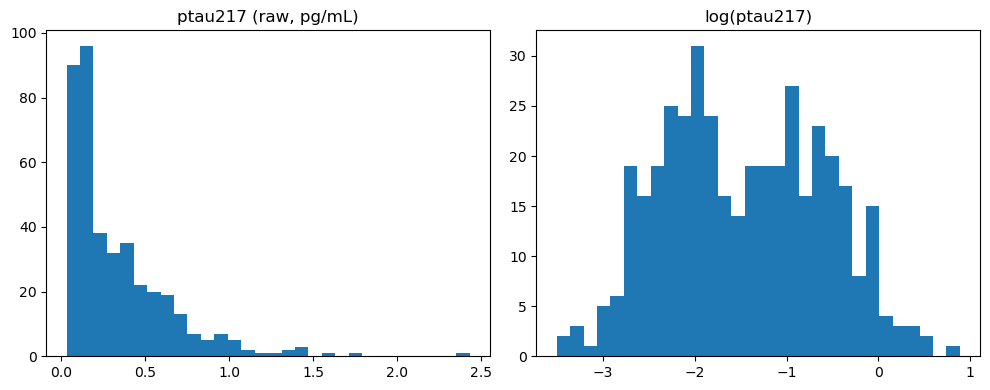

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df["ptau217"], bins=30)
axes[0].set_title("ptau217 (raw, pg/mL)")
axes[1].hist(np.log(df["ptau217"]), bins=30)
axes[1].set_title("log(ptau217)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/ptau217_distribution.png", dpi=150)
plt.show()

df["log_ptau217"] = np.log(df["ptau217"])

## 5. Fit Model 0 (age + APOE4) and Model 1 (+ p-tau217)
Both fit on the identical 401 participants / 85 events — the spec already
verified ptau217 has zero missingness, so adding it costs no sample.

In [13]:
cols0 = ["time_to_event_or_censor_days", "event_indicator", "entry_age", "APOE4_COUNT"]
cols1 = ["time_to_event_or_censor_days", "event_indicator", "entry_age", "APOE4_COUNT", "log_ptau217"]

cph0 = CoxPHFitter()
cph0.fit(df[cols0], duration_col="time_to_event_or_censor_days", event_col="event_indicator")

cph1 = CoxPHFitter()
cph1.fit(df[cols1], duration_col="time_to_event_or_censor_days", event_col="event_indicator")

print("=== Model 0: age + APOE4_COUNT ===")
cph0.print_summary(decimals=3)

print("\n=== Model 1: age + APOE4_COUNT + log(ptau217) ===")
cph1.print_summary(decimals=3)

=== Model 0: age + APOE4_COUNT ===


<lifelines.CoxPHFitter: fitted with 401 total observations, 316 right-censored observations>
             duration col = 'time_to_event_or_censor_days'
                event col = 'event_indicator'
      baseline estimation = breslow
   number of observations = 401
number of events observed = 85
   partial log-likelihood = -398.688
         time fit was run = 2026-07-12 22:02:26 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
entry_age   0.046     1.047     0.016           0.014           0.077               1.014               1.080
APOE4_COUNT 0.436     1.547     0.162           0.120           0.753               1.127               2.123

             cmp to     z     p  -log2(p)
covariate                                
entry_age     0.000 2.837 0.005     7.778
APOE4_COUNT   0.000 2.700 0.007     7.171
---
Concordance = 0.609
Partial AIC = 801.376
log-likelihood ratio test = 13.837 on 2 df
-log2(p) of ll-ratio test = 9.981


=== Model 1: age + APOE4_COUNT + log(ptau217) ===


<lifelines.CoxPHFitter: fitted with 401 total observations, 316 right-censored observations>
             duration col = 'time_to_event_or_censor_days'
                event col = 'event_indicator'
      baseline estimation = breslow
   number of observations = 401
number of events observed = 85
   partial log-likelihood = -367.819
         time fit was run = 2026-07-12 22:02:26 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
entry_age   0.016     1.016     0.017          -0.018           0.050               0.983               1.051
APOE4_COUNT 0.050     1.051     0.170          -0.284           0.384               0.753               1.468
log_ptau217 1.091     2.977     0.133           0.830           1.352               2.292               3.866

             cmp to     z       p  -log2(p)
covariate                                  
entry_age     0.000 0.939   0.348     1.523
APOE4_COUNT   0.000 0.293   0.770     0.378
log_ptau217   0.000 8.181 <0.0005    51.663
---
Concordance = 0.778
Partial AIC = 741.637
log-likelihood ratio test = 75.575 on 3 df
-log2(p) of ll-ratio test = 51.703

## 6. Model comparison (likelihood ratio test) + C-index
LR test is the right comparison here: Model 0 is nested in Model 1 (one
added parameter), and both are fit on the same 401/85 sample (spec §5).

In [14]:
lr_stat = 2 * (cph1.log_likelihood_ - cph0.log_likelihood_)
lr_df = cph1.params_.shape[0] - cph0.params_.shape[0]
lr_p = chi2.sf(lr_stat, df=lr_df)

comparison = pd.DataFrame({
    "model": ["Model 0 (age + APOE4)", "Model 1 (+ log ptau217)"],
    "n": [cph0.event_observed.shape[0], cph1.event_observed.shape[0]],
    "events": [int(cph0.event_observed.sum()), int(cph1.event_observed.sum())],
    "log_likelihood": [cph0.log_likelihood_, cph1.log_likelihood_],
    "concordance_apparent": [cph0.concordance_index_, cph1.concordance_index_],
    "AIC": [cph0.AIC_partial_, cph1.AIC_partial_],
})
print(comparison.to_string(index=False))
print(f"\nLikelihood ratio test (Model 1 vs Model 0): "
      f"LR = {lr_stat:.2f}, df = {lr_df}, p = {lr_p:.3g}")

comparison.to_csv(f"{TABLE_DIR}/model_comparison.csv", index=False)

                  model   n  events  log_likelihood  concordance_apparent        AIC
  Model 0 (age + APOE4) 401      85     -398.687774              0.608607 801.375547
Model 1 (+ log ptau217) 401      85     -367.818584              0.778310 741.637169

Likelihood ratio test (Model 1 vs Model 0): LR = 61.74, df = 1, p = 3.92e-15


**Note on C-index:** the values above are *apparent* (in-sample) concordance —
they will be optimistic. Section 10 computes a bootstrap-corrected version
for anything you plan to report as a performance estimate.

## 7. Proportional-hazards assumption check
lifelines' Schoenfeld-residual test (rank transform is the standard, less
sensitive to outlier follow-up times than the identity transform).

             test_statistic         p  -log2(p)
APOE4_COUNT        0.242423  0.622461  0.683944
entry_age          0.611810  0.434107  1.203878
log_ptau217        0.099563  0.752354  0.410516

   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


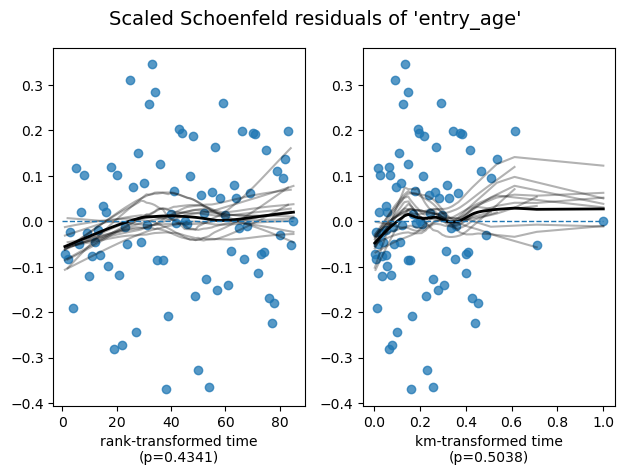

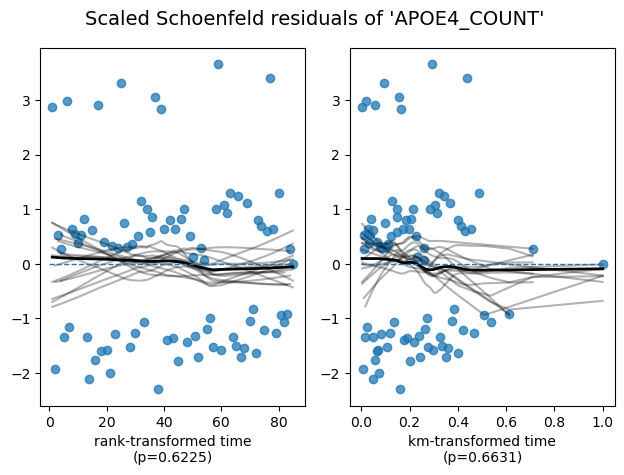

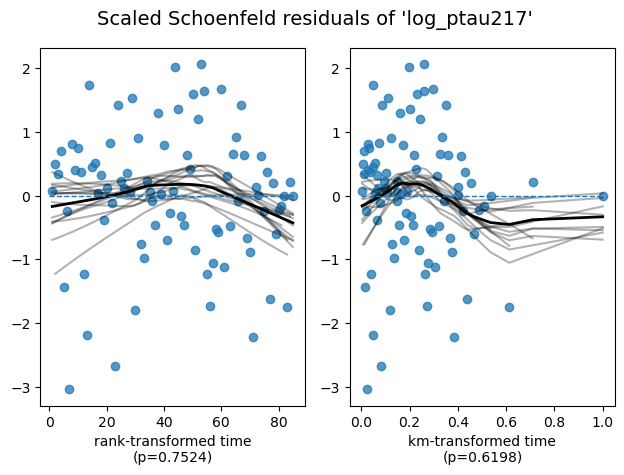

In [15]:
ph_test = proportional_hazard_test(cph1, df[cols1], time_transform="rank")
print(ph_test.summary)

cph1.check_assumptions(df[cols1], p_value_threshold=0.05, show_plots=True)
plt.savefig(f"{FIG_DIR}/ph_assumption_check.png", dpi=150)

**How to read this:** a low p-value (< 0.05) for a covariate flags a
possible PH violation for that variable specifically — it does not
invalidate the whole model, but warrants a note in the write-up (e.g. "the
effect may not be constant across follow-up"; consider a time-varying
term or a restricted follow-up window as a sensitivity check, not as a
replacement for the primary model).

## 8. Predicted risk at 2 years and 4 years
`predict_survival_function` gives S(t | x); risk = 1 - S(t | x).

In [16]:
horizons_days = {"2yr": 2 * 365.25, "4yr": 4 * 365.25}
surv_at_horizons = cph1.predict_survival_function(df[cols1], times=list(horizons_days.values()))
surv_at_horizons.index = list(horizons_days.keys())
risk_df = 1 - surv_at_horizons.T
risk_df.columns = ["predicted_risk_2yr", "predicted_risk_4yr"]
risk_df.index = df["RID"].values
risk_df.insert(0, "RID", risk_df.index)
risk_df.reset_index(drop=True, inplace=True)

print(risk_df.describe())
risk_df.to_csv(f"{TABLE_DIR}/predicted_risk_2yr_4yr.csv", index=False)

df = df.merge(risk_df, on="RID", how="left")

                RID  predicted_risk_2yr  predicted_risk_4yr
count    401.000000          401.000000          401.000000
mean    6353.199501            0.134696            0.391513
std     3055.348294            0.120315            0.254702
min        8.000000            0.009633            0.039391
25%     4809.000000            0.044117            0.170830
50%     6640.000000            0.091787            0.329495
75%     7088.000000            0.192192            0.587753
max    10878.000000            0.794512            0.998598


## 9. Risk groups — presentation only, not a clinical cutoff
Tertiles of *linear predictor* (log partial hazard), not of raw risk %,
and not chosen to optimize separation — that would be exactly the
data-dredged cutoff the project wants to avoid. Tertiles are used purely
to make a readable Kaplan–Meier plot; they are not proposed as a
diagnostic threshold.

In [17]:
df["lp"] = cph1.predict_log_partial_hazard(df[cols1])
df["risk_group"] = pd.qcut(df["lp"], q=3, labels=["Low", "Intermediate", "High"])
print(df["risk_group"].value_counts())

risk_group
Low             134
High            134
Intermediate    133
Name: count, dtype: int64


## 10. Kaplan–Meier curves by risk group + log-rank test

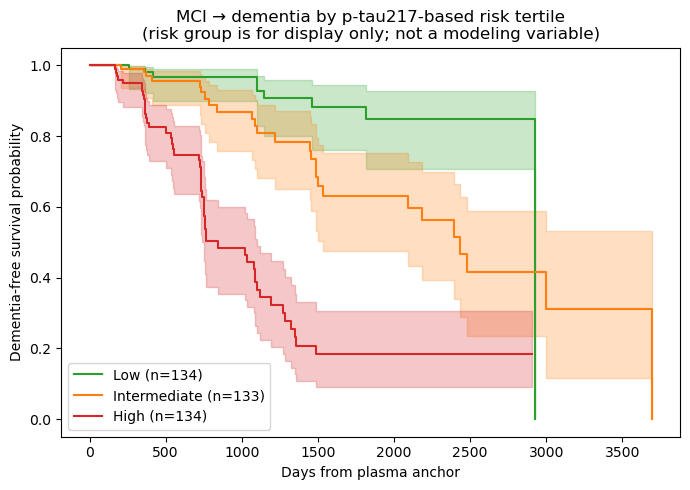

   test_statistic             p   -log2(p)
0       81.579762  1.928323e-18  58.847359


In [18]:
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(7, 5))
for grp, color in zip(["Low", "Intermediate", "High"], ["tab:green", "tab:orange", "tab:red"]):
    mask = df["risk_group"] == grp
    kmf.fit(df.loc[mask, "time_to_event_or_censor_days"],
            df.loc[mask, "event_indicator"], label=f"{grp} (n={mask.sum()})")
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True)

ax.set_xlabel("Days from plasma anchor")
ax.set_ylabel("Dementia-free survival probability")
ax.set_title("MCI → dementia by p-tau217-based risk tertile\n(risk group is for display only; not a modeling variable)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/km_by_risk_group.png", dpi=150)
plt.show()

# Overall log-rank test across the three groups (informal — three-group
# comparison is a stand-in for "does the model separate curves at all",
# not a formal hypothesis test replacing the Cox model itself)
from lifelines.statistics import multivariate_logrank_test
lr = multivariate_logrank_test(df["time_to_event_or_censor_days"], df["risk_group"], df["event_indicator"])
print(lr.summary)

## 11. Internal validation: bootstrap-corrected C-index
"Good enough for this project": simple nonparametric bootstrap
(resample participants with replacement, refit, evaluate apparent vs.
out-of-bag concordance). With 85 events, a full k-fold CV loop is more
fragile (each fold has ~17 events); bootstrap optimism-correction is the
standard, more stable choice at this sample size (Harrell's approach).

In [19]:
rng = np.random.default_rng(20260712)
n_boot = 200
optimism = []

for b in range(n_boot):
    boot_idx = rng.integers(0, len(df), len(df))
    boot_df = df.iloc[boot_idx].reset_index(drop=True)

    m = CoxPHFitter()
    try:
        m.fit(boot_df[cols1], duration_col="time_to_event_or_censor_days", event_col="event_indicator")
    except Exception:
        continue  # occasional non-convergent bootstrap resample; skip and continue

    c_boot_on_boot = m.concordance_index_
    lp_orig = m.predict_log_partial_hazard(df[cols1])
    c_boot_on_orig = concordance_index(df["time_to_event_or_censor_days"], -lp_orig, df["event_indicator"])
    optimism.append(c_boot_on_boot - c_boot_on_orig)

optimism = np.array(optimism)
apparent_c = cph1.concordance_index_
corrected_c = apparent_c - optimism.mean()

print(f"Apparent C-index (Model 1, in-sample): {apparent_c:.3f}")
print(f"Bootstrap optimism estimate ({len(optimism)} successful resamples): {optimism.mean():.3f}")
print(f"Optimism-corrected C-index: {corrected_c:.3f}")

pd.DataFrame({"apparent_c": [apparent_c], "optimism": [optimism.mean()],
              "corrected_c": [corrected_c], "n_boot": [len(optimism)]}
             ).to_csv(f"{TABLE_DIR}/bootstrap_validation.csv", index=False)

Apparent C-index (Model 1, in-sample): 0.778
Bootstrap optimism estimate (200 successful resamples): 0.004
Optimism-corrected C-index: 0.774


## 12. Export summary tables

In [20]:
def hr_table(cph, name):
    s = cph.summary.copy()
    out = pd.DataFrame({
        "model": name,
        "covariate": s.index,
        "HR": np.exp(s["coef"]),
        "HR_lower95": np.exp(s["coef lower 95%"]),
        "HR_upper95": np.exp(s["coef upper 95%"]),
        "p_value": s["p"],
    })
    return out

hr_tab = pd.concat([hr_table(cph0, "Model 0"), hr_table(cph1, "Model 1")], ignore_index=True)
print(hr_tab.to_string(index=False))
hr_tab.to_csv(f"{TABLE_DIR}/hazard_ratios.csv", index=False)

print("\nAll tables written to:", TABLE_DIR)
print("All figures written to:", FIG_DIR)

  model   covariate       HR  HR_lower95  HR_upper95      p_value
Model 0   entry_age 1.046838    1.014250    1.080473 4.555669e-03
Model 0 APOE4_COUNT 1.546836    1.126981    2.123108 6.937157e-03
Model 1   entry_age 1.016256    0.982607    1.051056 3.479157e-01
Model 1 APOE4_COUNT 1.051153    0.752687    1.467970 7.697104e-01
Model 1 log_ptau217 2.976782    2.292214    3.865796 2.804763e-16

All tables written to: ../outputs/tables
All figures written to: ../outputs/figures
